In [ ]:
!pip install jaxopt

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jaxopt import LBFGS

In [ ]:
seed = 0
key = jax.random.key(seed)
jax.config.update("jax_enable_x64", True)

In [ ]:
def project(v,n):
  return v-jnp.dot(v,n)/jnp.dot(n,n)*n

def log_r(x, xi, nx, y, xi_prime, ny, beta):
  phi = 0.5*jnp.log(jnp.dot(nx,nx)/jnp.dot(ny,ny))
  gaussian_term = (jnp.linalg.norm(x) + jnp.linalg.norm(y))*(jnp.linalg.norm(x)-jnp.linalg.norm(y))
  proposal_term = (jnp.linalg.norm(xi)+jnp.linalg.norm(xi_prime))*(jnp.linalg.norm(xi)-jnp.linalg.norm(xi_prime))
  return phi + 0.5 * gaussian_term + (1 / (2 * beta**2)) * proposal_term

def compute_reverse(x, y, n, beta):
    return project(x-jnp.sqrt(1-beta**2)*y, n)

In [ ]:
alpha = -1
beta = 1

In [ ]:
def manifold(d,z=0):

  x_0 = jnp.float64(0.1)
  tt = 1
  dt = tt/d
  dW = jnp.sqrt(dt)
  t0=dt

  def diffusion(x):
    return beta*x

  def drift(x):
    return alpha*x

  def pathstep(curr, rand_var):
    (x_i,A_i) = curr
    step = drift(x_i)*dt + diffusion(x_i)*dW*rand_var
    A_i += x_i*dt + 0.5*step*dt
    x_i += step
    return (x_i, A_i), x_i

  def F_full(x):
    (end, A), sample_path = jax.lax.scan(pathstep, (x_0,0.0) ,x)
    return A - z, (sample_path,end)

  def F(x):
    out, _ = F_full(x)
    return out

  def x0():
    def h(x):
      return 0.5*jnp.dot(x,x)
    c = 1e6
    def pen(x):
      (_, final), _ = jax.lax.scan(pathstep,(x_0,0.0),x)
      return c*(final-z)**2
    def J(x):
      return h(x) + pen(x)
    init = jax.random.normal(jax.random.key(seed+1),shape=(d,))
    solver = LBFGS(fun=J,maxiter=100,tol=1e-3)
    solns = solver.run(init)
    return solns.params

  def nx0():
    return jax.grad(F,allow_int=True)(x0())

  def manifoldproject(x, n, tol=1e-3, maxiter=100):
    def f(val):
      a,i = val
      ff = lambda a: F(x + a * n)
      fff = ff(a)
      dff = jax.grad(ff)(a)
      return (a-fff/dff, i+1)
    def cond(val):
      a,i = val
      return jnp.logical_and(jnp.abs(F(x + a * n))>tol,i<maxiter)
    a,_ = jax.lax.while_loop(cond, f, (0.0,0))
    success = lambda a: jnp.abs(F(x + a * n))<tol
    return jnp.where(success(a), x + a * n, x)

  return F, x0, nx0, manifoldproject, F_full

In [ ]:
def PCN_paths(beta=0.1, d=jnp.int32(1e5), burnin=1000, N=0, z=0):
    F, x0, nx0, manifoldproject, F_full = manifold(d,z=z)
    keylist = jax.random.split(key, N+burnin)

    @jax.jit
    def sampleStep(carry, current_key):
        (x, nx, accs, it) = carry

        rho = jnp.sqrt(1-beta**2)
        xi = beta * project(jax.random.normal(current_key,shape=x.shape), nx)
        v = project((rho-1)*x, nx) + xi
        y = manifoldproject(x+v,nx)
        ny = jax.grad(F)(y)
        xi_prime = compute_reverse(x, y, ny, beta)
        R = log_r(x, xi, nx, y, xi_prime, ny, beta)
        acc = (jnp.log(jax.random.uniform(current_key)) < R)
        x = jnp.where(acc, y, x)
        nx = jnp.where(acc, ny, nx)
        accs += jnp.where(it>burnin,acc,0)
        it += 1
        return (x, nx, accs, it), (R,x)

    (eta, _, accs, _), (Rs,xs) = jax.lax.scan(sampleStep, (x0(), nx0(), 0, 0), keylist)
    err, (path,_) = F_full(eta)
    stats = [np.mean(Rs[burnin:]), accs/(N+burnin)]
    sample_path = np.array(path)
    plt.xlabel('timesteps')
    plt.ylabel('X_t')
    plt.title('GBM Conditioned Sample Paths')
    plt.plot(range(len(sample_path)),sample_path)
    print('Accepted:', accs, 'out of', N+burnin)
    print('Error:', err)

    return None

Accepted: 997 out of 1000
Error: 4.356675420424949e-06
Accepted: 1497 out of 1500
Error: 4.193381904382676e-06
Accepted: 1995 out of 2000
Error: -0.000873505288197518


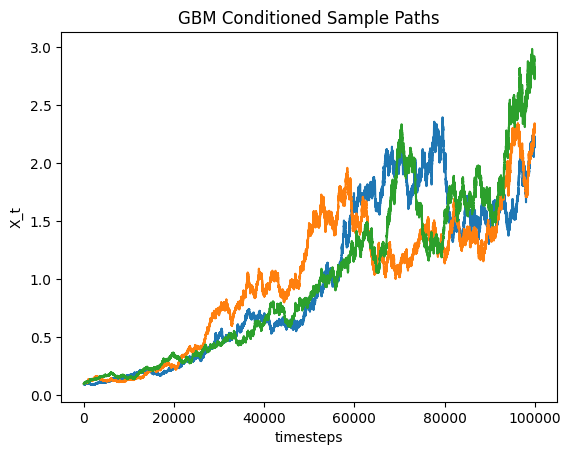

In [ ]:
PCN_paths(z=1)
PCN_paths(z=1,N=500)
PCN_paths(z=1,N=1000)

In [ ]:
def PCN(beta=0.1, d=jnp.int32(1e5), burnin=1000, N=1000, z=1):
    F, x0, nx0, manifoldproject, F_full = manifold(d,z=z)
    keylist = jax.random.split(key, N+burnin)

    @jax.jit
    def sampleStep(carry, current_key):
        (x, nx, it) = carry

        rho = jnp.sqrt(1-beta**2)
        xi = beta * project(jax.random.normal(current_key,shape=x.shape), nx)
        v = project((rho-1)*x, nx) + xi
        y = manifoldproject(x+v,nx)
        ny = jax.grad(F)(y)
        xi_prime = compute_reverse(x, y, ny, beta)
        R = log_r(x, xi, nx, y, xi_prime, ny, beta)
        acc = (jnp.log(jax.random.uniform(current_key)) < R)
        x = jnp.where(acc, y, x)
        nx = jnp.where(acc, ny, nx)
        it += 1
        _, (_, end) = F_full(x)
        return (x, nx, it), end

    _, ends = jax.lax.scan(sampleStep, (x0(), nx0(), 0), keylist)

    return np.array(ends[burnin:])

In [ ]:
endpoints = PCN()

Mean: 2.3080554610857797
Standard deviation: 0.4783736530846934
Skew: 0.05158948165710824


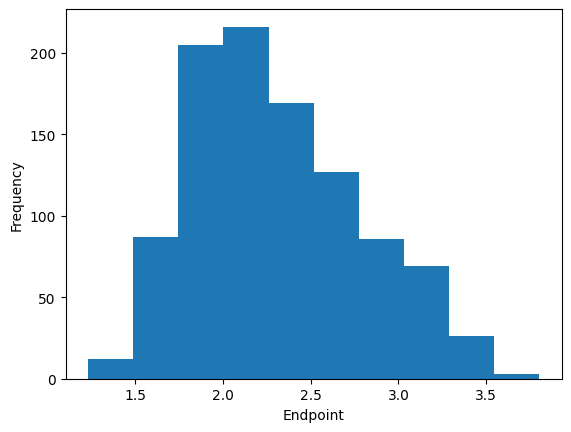

In [ ]:
plt.hist(endpoints)
plt.xlabel('Endpoint')
plt.ylabel('Frequency')
plt.savefig('distribution.png')
print('Mean:',np.mean(endpoints))
print('Standard deviation:',np.std(endpoints))
print('Skew:',np.mean((endpoints-np.mean(endpoints))**3))